<a href="https://colab.research.google.com/github/lexinejazly-asuncion/Sign-Language-Classification/blob/main/Sign_Language_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Install Required Python Libraries and Dependencies**

In [1]:
!pip install pandas
!pip install pillow
!pip install kaggle
!pip install scikit-learn
!pip install torchvision

#**Load Data**

In [2]:
from pathlib import Path
import zipfile

dataset_folder = Path("dataset/SigNN Character Database")
zip_path = Path("dataset/asl-sign-language-pictures-minus-j-z.zip")

if not zip_path.exists():
    !kaggle datasets download -d signnteam/asl-sign-language-pictures-minus-j-z -p dataset
else:
    print("Zip file already downloaded.")

if not dataset_folder.exists():
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall("dataset")
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

Dataset URL: https://www.kaggle.com/datasets/signnteam/asl-sign-language-pictures-minus-j-z
License(s): CC-BY-NC-SA-4.0
100% 1.66G/1.66G [00:55<00:00, 32.0MB/s]

Dataset extracted.


# **EDA**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
data_path = Path("dataset/SigNN Character Database")

paths = [path.parts[-2:] for path in data_path.rglob("*.*")] #gives the class and image file name

sl_df = pd.DataFrame(data=paths, columns=["Class","Images"]) #create column names for dataframe
sl_df = sl_df.sort_values("Class",ascending=True)
sl_df.reset_index(drop=True, inplace=True)
sl_df.head()

,Class,Images
0,A,75.jpg
1,A,214.jpg
2,A,199.jpg
3,A,411.jpg
4,A,425.jpg


## **Dataset Size and Class Distribution**

Total images in dataset: 8442
Total classes: 24

Total images per class:
{'B': 541, 'A': 539, 'E': 498, 'F': 420, 'C': 387, 'D': 379, 'O': 374, 'H': 364, 'I': 360, 'W': 347, 'L': 346, 'G': 345, 'V': 337, 'K': 319, 'Y': 318, 'S': 314, 'X': 310, 'T': 301, 'N': 293, 'R': 291, 'U': 286, 'M': 277, 'Q': 275, 'P': 221}


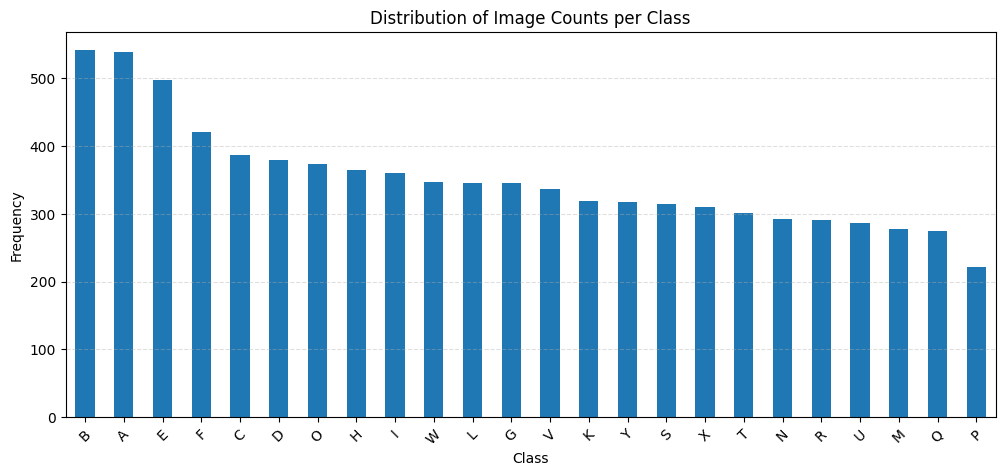

In [5]:
print(f"Total images in dataset: {len(sl_df)}")
print(f"Total classes: {sl_df['Class'].nunique()}")
print("\nTotal images per class:")

class_counts = sl_df["Class"].value_counts()
print(class_counts.to_dict())

class_counts.plot(kind="bar", figsize=(12,5))
plt.xticks(rotation=45)
plt.title('Distribution of Image Counts per Class')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.4)


## **Extracting Image Dimensions**

In [6]:
from PIL import Image
import os

#finds dimensions of each image
def get_img_dim(x):
  img_path = os.path.join(data_path, x["Class"], x["Images"])
  with Image.open(img_path) as img:
    return img.size

#creates two new columns in df: width and height
sl_df[["Width", "Height"]] = sl_df.apply(get_img_dim, axis=1, result_type="expand")
sl_df.head()

,Class,Images,Width,Height
0,A,75.jpg,640,480
1,A,214.jpg,640,480
2,A,199.jpg,640,480
3,A,411.jpg,640,480
4,A,425.jpg,640,480


### **Image sizes per class**

In [7]:
#finds the different dimensions of each class
img_sizes = sl_df.groupby('Class').apply(
    lambda x: x[['Width', 'Height']].drop_duplicates().apply(
        lambda x: f"{int(x['Width'])}x{int(x['Height'])}", axis=1).tolist(), include_groups=False
)

print(f"Image sizes per class: {img_sizes}")


Image sizes per class: Class
A              [640x480, 1920x1920]
B              [640x480, 1920x1920]
C              [1920x1920, 640x480]
D              [640x480, 1920x1920]
E              [1920x1920, 640x480]
F              [640x480, 1920x1920]
G              [640x480, 1920x1920]
H              [640x480, 1920x1920]
I              [640x480, 1920x1920]
K              [640x480, 1920x1920]
L              [640x480, 1920x1920]
M              [640x480, 1920x1920]
N    [640x480, 1920x1920, 1280x720]
O              [640x480, 1920x1920]
P              [640x480, 1920x1920]
Q    [640x480, 1280x720, 1920x1920]
R              [640x480, 1920x1920]
S    [640x480, 1280x720, 1920x1920]
T              [1920x1920, 640x480]
U              [640x480, 1920x1920]
V    [1280x720, 1920x1920, 640x480]
W    [640x480, 1920x1920, 1280x720]
X              [640x480, 1920x1920]
Y              [640x480, 1920x1920]
dtype: object


### **Distribution of Image Resolutions by Class**

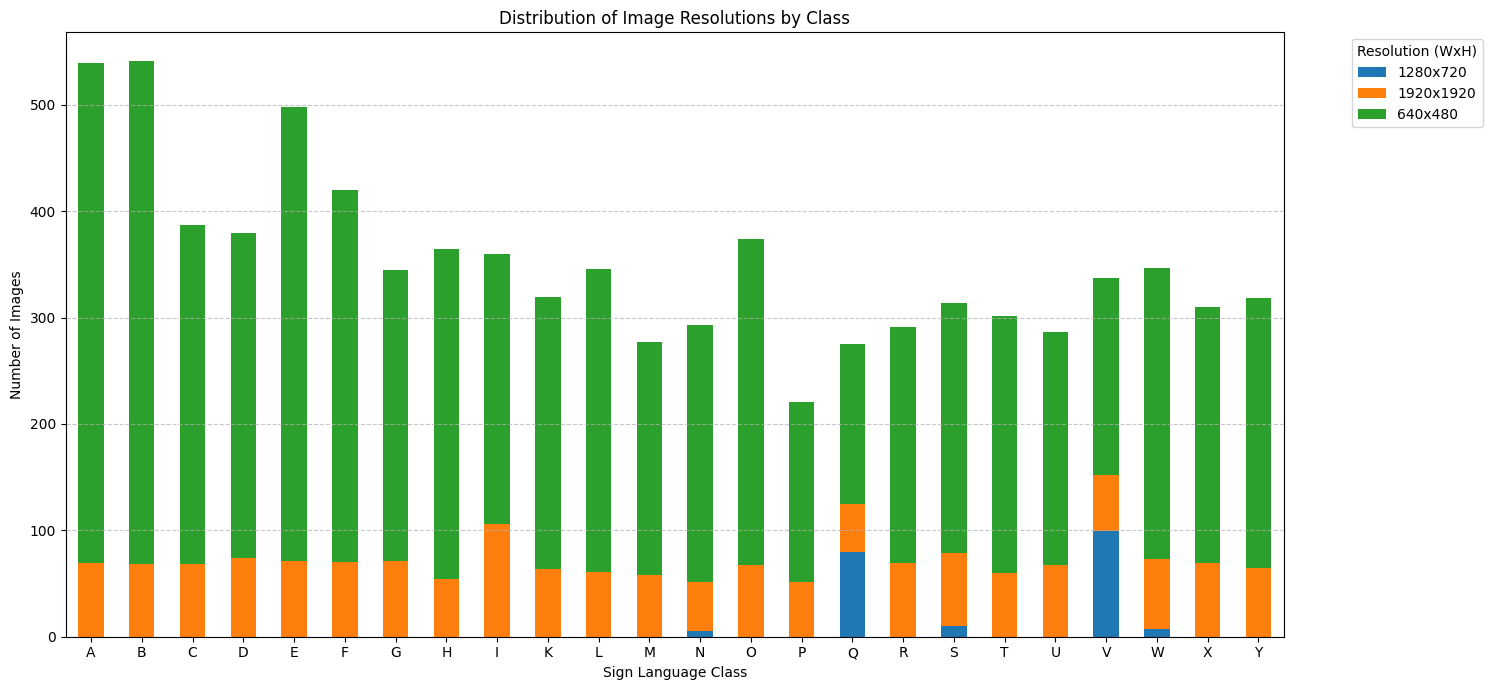

In [8]:
sl_df['Size'] = sl_df['Width'].astype(str) + 'x' + sl_df['Height'].astype(str)

size_pivot = sl_df.groupby(['Class', 'Size']).size().unstack(fill_value=0)

size_pivot.plot(kind='bar', stacked=True, figsize=(15, 7))

plt.title('Distribution of Image Resolutions by Class')
plt.xlabel('Sign Language Class')
plt.ylabel('Number of Images')
plt.legend(title='Resolution (WxH)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# **Preprocessing**

In [9]:
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

### **Train, Validation, and Test Data Split**

In [10]:
#split data: 70% train, 10% validation, 20%test
temp, test_set = train_test_split(sl_df, test_size=0.2, stratify=sl_df["Class"], random_state=42)
train_set, val_set = train_test_split(temp, test_size=0.125, stratify=temp["Class"], random_state=42)

print("Training Set Distribution:")
print(train_set["Class"].value_counts())

print("\nValidation Set Distribution:")
print(val_set["Class"].value_counts())

print("\nTest Set Distribution:")
print(test_set["Class"].value_counts())

print("\nTrain Set Size:", len(train_set))
print("Validation Set Size:", len(val_set))
print("Test Set Size:", len(test_set))



Training Set Distribution:
Class
B    379
A    377
E    348
F    294
C    270
D    265
O    262
H    255
I    252
W    243
L    242
G    241
V    236
K    223
Y    222
S    220
X    217
T    211
N    205
R    204
U    200
M    194
Q    193
P    155
Name: count, dtype: int64

Validation Set Distribution:
Class
B    54
A    54
E    50
F    42
C    39
D    38
O    37
H    36
I    36
L    35
W    35
G    35
V    34
K    32
Y    32
X    31
S    31
T    30
R    29
N    29
U    29
M    28
Q    27
P    22
Name: count, dtype: int64

Test Set Distribution:
Class
A    108
B    108
E    100
F     84
C     78
D     76
O     75
H     73
I     72
L     69
W     69
G     69
V     67
Y     64
K     64
S     63
X     62
T     60
N     59
R     58
U     57
M     55
Q     55
P     44
Name: count, dtype: int64

Train Set Size: 5908
Validation Set Size: 845
Test Set Size: 1689


### **Custom Dataset Class and Image Preprocessing Pipelines**

In [11]:
class ASLDataset(Dataset):
    def __init__(self, df, data_path, transform=None):
        self.df = df
        self.data_path = data_path
        self.transform = transform
        self.label_map = {label: i for i, label in enumerate(sorted(df['Class'].unique()))} #for label encoding

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.data_path, row["Class"], row["Images"])

        image = Image.open(img_path).convert("RGB") #transform image to color
        label = self.label_map[row["Class"]] #labels represented as ints

        if self.transform:
            image = self.transform(image) #apply the transformation

        return image, label

train_preprocess_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ToTensor(), #scale and reshape data to a tensor
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) #normalize to [-1,1]
])

val_test_preprocess_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(), #scale and reshape data to a tensor
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) #normalize to [-1,1]
])

### **Balanced Training Set and DataLoader Initialization**

In [12]:
#balanced undersampling, 150 each class
train_set_balanced = train_set.groupby("Class").sample(n=150, random_state=42).reset_index(drop=True)

train_dataset = ASLDataset(train_set_balanced, data_path, transform=train_preprocess_pipeline) #preprocess data
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) #loads data into the model

val_dataset = ASLDataset(val_set, data_path, transform=val_test_preprocess_pipeline)
val_loader = DataLoader(val_dataset, batch_size=32) #shuffle=False

test_dataset = ASLDataset(test_set, data_path, transform=val_test_preprocess_pipeline)
test_loader = DataLoader(test_dataset, batch_size=32) #shuffle=False

# **Training**

## **Initial Custom CNN Model**



In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report

# make sure test labels match training labels
test_dataset.label_map = train_dataset.label_map


#custom cnn
class ASLCNN(nn.Module):
    def __init__(self, num_classes=24):
        super(ASLCNN, self).__init__()

        #feature extraction
        self.features = nn.Sequential(
            #CONVOLUTION LAYERS

            #FIRST CONV BLOCK
            #first conv layer
            #takes rgb image (3 channels) and creates 32 feature maps
            #learns edges, outlines, curves, shadows

            nn.Conv2d(3, 32, kernel_size=3, padding=1),

            #second conv layer
            #ReLu keeps important positive signals, removes weak neg values
            nn.ReLU(),

            #third conv layer
            #shrinks image size by half for faster computation
            nn.MaxPool2d(2, 2),


            #takes 32 feature maps as input and outputs 64 feature maps
            #this layer looks for detailed hand patterns, finger arrangement, thumb position
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            #takes 64 maps as input, outputs 128 maps
            #model learns complete hand shapes, overall ASL sign structure
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            #flatten layer
            #turns 128 feature maps of size 28x28 -> one long vector
            #ready for dense layer now that its 1D
            nn.Flatten(),

            #dense layer
            #outputs 256 learned features
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),

            #dropout
            #prevents memorization and model can generalize better
            nn.Dropout(0.3),

            #final output layer
            #24 probabilites
            #ex. A = 92%
            # B = %
            #highest probability wins
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# **Experiment \#1**

**Experiment 1: Initialize Custom CNN Model, Loss Function, and Optimizer**

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ASLCNN(num_classes=24).to(device)

print("Initialized on: ", device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Initialized on:  cuda


**Experiment 1: Custom CNN Training and Validation Loop (5 Epochs)**

In [15]:
#Train and Validation Set

import time

start = time.time()

epochs = 5

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(epochs):
    #test
    model.train()
    running_train_loss = 0

    train_preds = []
    train_labels = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    #validation
    model.eval()
    running_val_loss = 0
    correct = 0
    total = 0

    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    #epoch metrics: train loss and accuracy
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = accuracy_score(train_labels, train_preds)


    #epoch metrics: validation loss and accuracy
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = accuracy_score(val_labels, val_preds)

    #store metrics
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"TRAIN Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f}")
    print(f"VALIDATION Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}")


end = time.time()

print(f"Execution time: {end - start:.2f} seconds")

Epoch [1/5]
TRAIN Loss: 0.0825, Acc: 0.2300
VALIDATION Loss: 0.0516, Acc: 0.5124
Epoch [2/5]
TRAIN Loss: 0.0465, Acc: 0.5561
VALIDATION Loss: 0.0384, Acc: 0.6260
Epoch [3/5]
TRAIN Loss: 0.0337, Acc: 0.6622
VALIDATION Loss: 0.0310, Acc: 0.7101
Epoch [4/5]
TRAIN Loss: 0.0264, Acc: 0.7303
VALIDATION Loss: 0.0259, Acc: 0.7598
Epoch [5/5]
TRAIN Loss: 0.0212, Acc: 0.7856
VALIDATION Loss: 0.0246, Acc: 0.7953
Execution time: 365.09 seconds


### **Experiment 1: Training and Validation Performance Graphs**

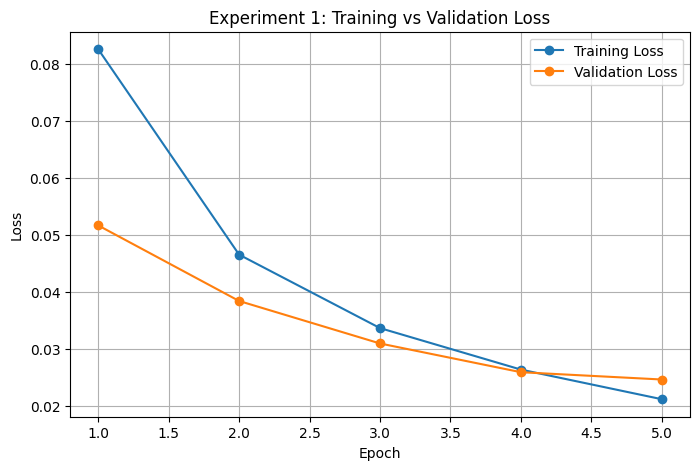

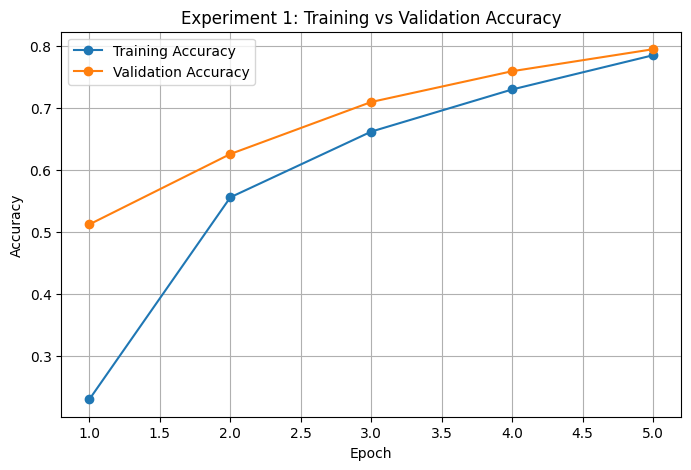

In [16]:
#Experiment 1 training/validation graph

import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, marker="o", label="Training Loss")
plt.plot(epochs_range, val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 1: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_accuracies, marker="o", label="Training Accuracy")
plt.plot(epochs_range, val_accuracies, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment 1: Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# **Experiment \#2: Increase the number of epochs to 10**

**Experiment 2: Initialize Custom CNN Model, Loss Function, and Optimizer**

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ASLCNN(num_classes=24).to(device)

print("Initialized on: ", device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Initialized on:  cuda


**Experiment 2: Custom CNN Training and Validation Loop (10 Epochs)**

In [18]:
#Train and Validation Set

import time

start = time.time()

epochs = 10

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(epochs):
    #test
    model.train()
    running_train_loss = 0

    train_preds = []
    train_labels = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    #validation
    model.eval()
    running_val_loss = 0
    correct = 0
    total = 0

    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    #epoch metrics: train loss and accuracy
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = accuracy_score(train_labels, train_preds)


    #epoch metrics: validation loss and accuracy
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = accuracy_score(val_labels, val_preds)

    #store metrics
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"TRAIN Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f}")
    print(f"VALIDATION Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}")

end = time.time()

print(f"Execution time: {end - start:.2f} seconds")

Epoch [1/10]
TRAIN Loss: 0.0770, Acc: 0.2928
VALIDATION Loss: 0.0495, Acc: 0.5018
Epoch [2/10]
TRAIN Loss: 0.0450, Acc: 0.5717
VALIDATION Loss: 0.0370, Acc: 0.6994
Epoch [3/10]
TRAIN Loss: 0.0321, Acc: 0.6811
VALIDATION Loss: 0.0299, Acc: 0.7302
Epoch [4/10]
TRAIN Loss: 0.0257, Acc: 0.7550
VALIDATION Loss: 0.0241, Acc: 0.7964
Epoch [5/10]
TRAIN Loss: 0.0207, Acc: 0.7942
VALIDATION Loss: 0.0239, Acc: 0.7976
Epoch [6/10]
TRAIN Loss: 0.0168, Acc: 0.8333
VALIDATION Loss: 0.0226, Acc: 0.8071
Epoch [7/10]
TRAIN Loss: 0.0146, Acc: 0.8497
VALIDATION Loss: 0.0205, Acc: 0.8462
Epoch [8/10]
TRAIN Loss: 0.0120, Acc: 0.8792
VALIDATION Loss: 0.0215, Acc: 0.8391
Epoch [9/10]
TRAIN Loss: 0.0112, Acc: 0.8894
VALIDATION Loss: 0.0207, Acc: 0.8485
Epoch [10/10]
TRAIN Loss: 0.0096, Acc: 0.9039
VALIDATION Loss: 0.0208, Acc: 0.8497
Execution time: 747.57 seconds


**Experiment 2: Training and Validation Performance Graphs**

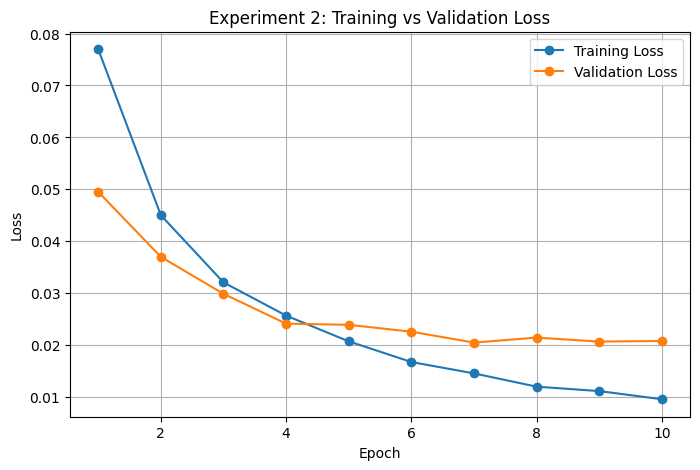

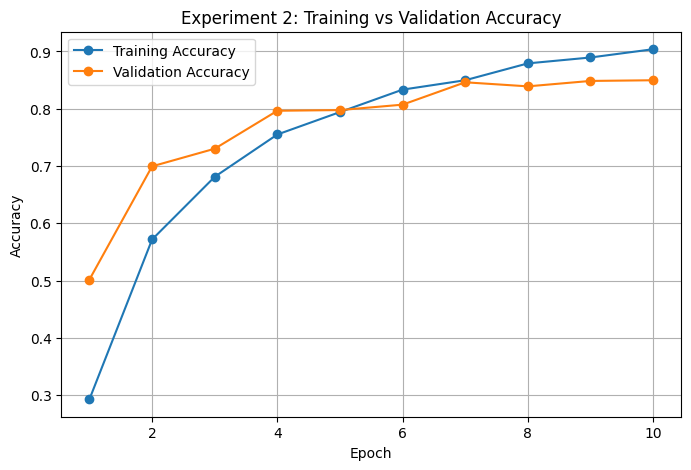

In [19]:
#Experiment 2: training/validation graph:

import matplotlib.pyplot as plt

exp2_train_losses = train_losses.copy()
exp2_val_losses = val_losses.copy()
exp2_train_accuracies = train_accuracies.copy()
exp2_val_accuracies = val_accuracies.copy()

epochs_range = range(1, len(exp2_train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, exp2_train_losses, marker="o", label="Training Loss")
plt.plot(epochs_range, exp2_val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 2: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, exp2_train_accuracies, marker="o", label="Training Accuracy")
plt.plot(epochs_range, exp2_val_accuracies, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment 2: Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# **Experiment \#3: Reduce number of epochs to 8, Add a 4th Layer**


### **Experiment 3: Enhanced Custom CNN Architecture with Additional Convolution Layer**

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report

test_dataset.label_map = train_dataset.label_map

class ASLCNN(nn.Module):
    def __init__(self, num_classes=24):
        super(ASLCNN, self).__init__()
        self.features = nn.Sequential(
            #convolutional layers
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### **Experiment 3: Initialize Enhanced Custom CNN Model, Loss Function, and Optimizer**

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ASLCNN(num_classes=24).to(device)

print("Initialized on: ", device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Initialized on:  cuda


### **Experiment 3: Enhanced Custom CNN Training and Validation Loop (8 Epochs)**

In [22]:
#Train and Validation Set

import time

start = time.time()

epochs = 8

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(epochs):
    #test
    model.train()
    running_train_loss = 0

    train_preds = []
    train_labels = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    #validation
    model.eval()
    running_val_loss = 0
    correct = 0
    total = 0

    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    #epoch metrics: train loss and accuracy
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = accuracy_score(train_labels, train_preds)


    #epoch metrics: validation loss and accuracy
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = accuracy_score(val_labels, val_preds)

    #store metrics
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"TRAIN Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f}")
    print(f"VALIDATION Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}")


end = time.time()

print(f"Execution time: {end - start:.2f} seconds")

Epoch [1/8]
TRAIN Loss: 0.0835, Acc: 0.2156
VALIDATIONLoss: 0.0594, Acc: 0.4391
Epoch [2/8]
TRAIN Loss: 0.0524, Acc: 0.4964
VALIDATIONLoss: 0.0418, Acc: 0.6130
Epoch [3/8]
TRAIN Loss: 0.0386, Acc: 0.6250
VALIDATIONLoss: 0.0324, Acc: 0.7183
Epoch [4/8]
TRAIN Loss: 0.0310, Acc: 0.6908
VALIDATIONLoss: 0.0302, Acc: 0.7491
Epoch [5/8]
TRAIN Loss: 0.0256, Acc: 0.7442
VALIDATIONLoss: 0.0265, Acc: 0.7822
Epoch [6/8]
TRAIN Loss: 0.0214, Acc: 0.7797
VALIDATIONLoss: 0.0253, Acc: 0.7917
Epoch [7/8]
TRAIN Loss: 0.0180, Acc: 0.8169
VALIDATIONLoss: 0.0278, Acc: 0.8000
Epoch [8/8]
TRAIN Loss: 0.0169, Acc: 0.8269
VALIDATIONLoss: 0.0231, Acc: 0.8284
Execution time: 594.44 seconds


### **Experiment 3: Enhanced Custom CNN Training and Validation Performance Graphs**

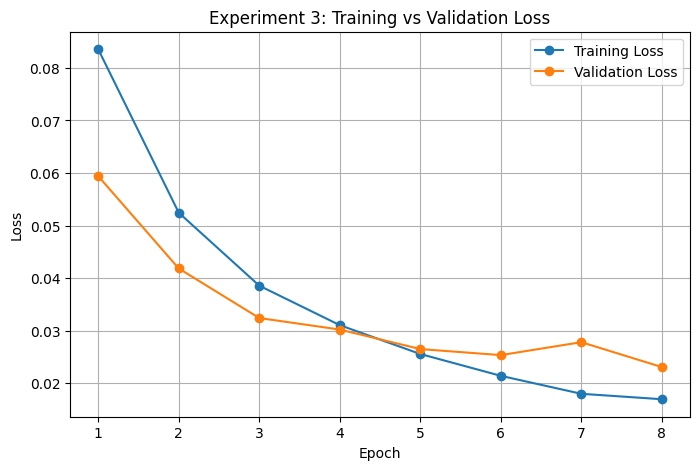

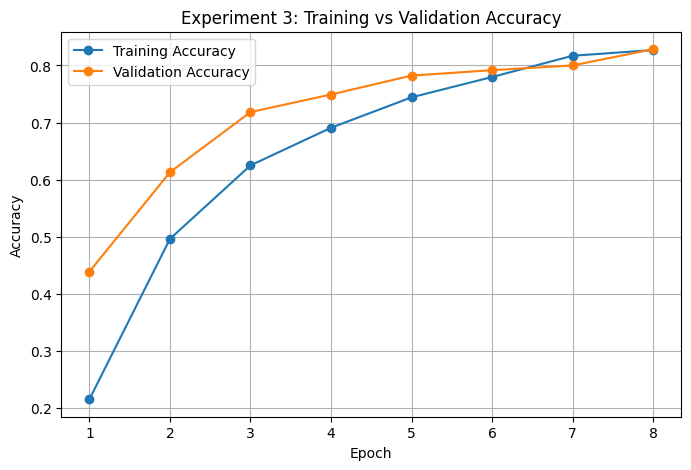

In [23]:
import matplotlib.pyplot as plt

exp3_train_losses = train_losses.copy()
exp3_val_losses = val_losses.copy()
exp3_train_accuracies = train_accuracies.copy()
exp3_val_accuracies = val_accuracies.copy()

epochs_range = range(1, len(exp3_train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, exp3_train_losses, marker="o", label="Training Loss")
plt.plot(epochs_range, exp3_val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 3: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, exp3_train_accuracies, marker="o", label="Training Accuracy")
plt.plot(epochs_range, exp3_val_accuracies, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment 3: Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## **Custom CNN Model Evaluation**

In [24]:
#Test Set
model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

        test_acc = accuracy_score(test_labels, test_preds)
        test_precision = precision_score(test_labels, test_preds, average='weighted')
        test_recall = recall_score(test_labels, test_preds, average='weighted')
        test_f1 = f1_score(test_labels, test_preds, average='weighted')

print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")

print(classification_report(test_labels, test_preds, target_names=list(train_dataset.label_map.keys())))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Accuracy:  0.8301
Precision: 0.8389
Recall:    0.8301
F1 Score:  0.8311
              precision    recall  f1-score   support

           A       0.91      0.81      0.86       108
           B       0.76      0.93      0.84       108
           C       0.95      0.95      0.95        78
           D       0.83      0.83      0.83        76
           E       0.87      0.76      0.81       100
           F       0.94      0.70      0.80        84
           G       0.85      0.77      0.81        69
           H       0.91      0.92      0.91        73
           I       0.79      0.81      0.80        72
           K       0.89      0.88      0.88        64
           L       0.87      0.87      0.87        69
           M       0.79      0.89      0.84        55
           N       0.91      0.90      0.91        59
           O       0.85      0.84      0.85        75
           P       0.91      0.91      0.91        44
           Q       0.86      0.93      0.89        55
         

### **Best Custom CNN Model - Confusion Matrix on Test Set**


<Figure size 1400x1400 with 0 Axes>

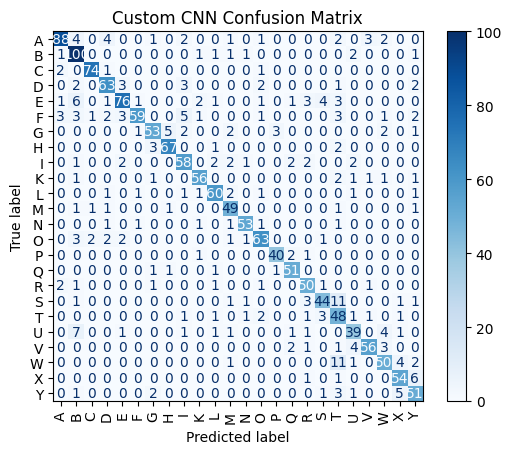

In [25]:
#CUSTOM CNN EXPERIMENT 3 VISUALIZATIONS
#Confusion Matrix and Prediction Analysis

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

#evaluate best custom cnn model on test set
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

#class labels for display
class_names = sorted(train_dataset.label_map.keys())

#create confusion matrix
cm = confusion_matrix(all_labels, all_preds)

#plot confusion matrix
plt.figure(figsize=(14, 14))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    values_format="d"
)

plt.title("Custom CNN Confusion Matrix")
plt.show()

### **Best Custom CNN Model - Sample Correct and Incorrect Predictions**

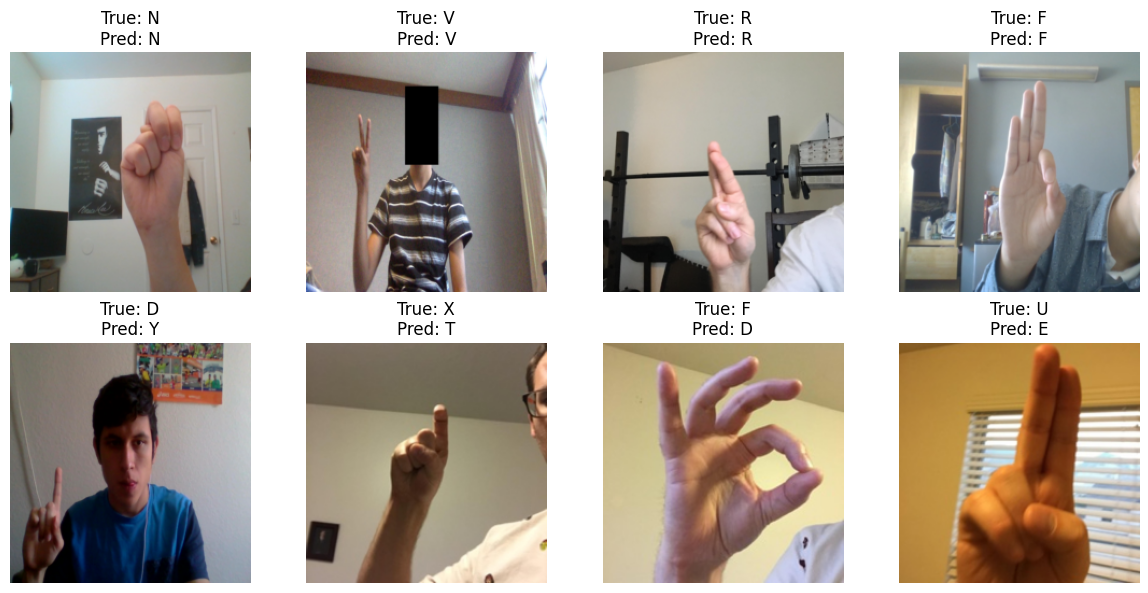

In [26]:
import matplotlib.pyplot as plt
import numpy as np

idx_to_class = {v: k for k, v in train_dataset.label_map.items()}

def show_image(img):
    img = img.cpu().permute(1, 2, 0).numpy()
    img = (img * 0.5) + 0.5
    img = np.clip(img, 0, 1)
    return img

model.eval()

correct_examples = []
incorrect_examples = []

with torch.no_grad():
    for images, labels in test_loader:
        images_device = images.to(device)
        labels_device = labels.to(device)

        outputs = model(images_device)
        _, preds = torch.max(outputs, 1)

        for img, true_label, pred_label in zip(images, labels, preds.cpu()):
            if true_label.item() == pred_label.item() and len(correct_examples) < 4:
                correct_examples.append((img, true_label.item(), pred_label.item()))
            elif true_label.item() != pred_label.item() and len(incorrect_examples) < 4:
                incorrect_examples.append((img, true_label.item(), pred_label.item()))

        if len(correct_examples) == 4 and len(incorrect_examples) == 4:
            break

examples = correct_examples + incorrect_examples

plt.figure(figsize=(12, 6))

for i, (img, true_label, pred_label) in enumerate(examples):
    plt.subplot(2, 4, i + 1)
    plt.imshow(show_image(img))
    plt.title(f"True: {idx_to_class[true_label]}\nPred: {idx_to_class[pred_label]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#**Pre-trained ResNet18: Regular vs Fine-Tuned Models**

In [27]:
from torchvision import models, transforms
import torch
import torch.nn as nn
import torch.optim as optim
import time
from sklearn.metrics import accuracy_score


# ResNet preprocessing
resnet_preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#load datasets with the ResNet preprocessing

train_dataset = ASLDataset(train_set, data_path, transform=resnet_preprocess)
val_dataset = ASLDataset(val_set, data_path, transform=resnet_preprocess)
test_dataset = ASLDataset(test_set, data_path, transform=resnet_preprocess)

# make sure val and test use same label mapping as train
val_dataset.label_map = train_dataset.label_map
test_dataset.label_map = train_dataset.label_map

# load data in batches
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


model = models.resnet18(pretrained=True)

# freeze all layers
for param in model.parameters():
    param.requires_grad = False


#swapping out the last layer to create 24 classes
model.fc = nn.Linear(model.fc.in_features, 24)

#use GPU else CPU
model = model.to(device)

#loss function
criterion = nn.CrossEntropyLoss()
#passing only the top last layer
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


epochs = 5
train_losses_fc = []
val_losses_fc = []
val_accuracies_fc = []
start = time.time()
print("Regular ResNet")


#begin training and validation

for epoch in range(epochs):
    model.train()
    running_train_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
    model.eval()
    running_val_loss = 0
    val_preds = []
    val_labels = []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = accuracy_score(val_labels, val_preds)
    train_losses_fc.append(epoch_train_loss)
    val_losses_fc.append(epoch_val_loss)
    val_accuracies_fc.append(epoch_val_acc)
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {epoch_train_loss:.4f}")
    print(f"Validation Loss: {epoch_val_loss:.4f}, Validation Accuracy: {epoch_val_acc:.4f}")
end = time.time()

print(f"ResNet FC only training time: {end - start:.2f} seconds")

#saved to draw the confusion matrix
model_fc = model

model = models.resnet18(pretrained=True)

#had to unfreeze layer4 to get better performance, otherwise the model was underfitting was
#getting around 80 %accuracy but after unfreezing layer4, accuracy jumped to around 97%
for param in model.layer4.parameters():
    param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, 24)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {"params": model.layer4.parameters(), "lr": 0.0001},
    {"params": model.fc.parameters(), "lr": 0.001}
])
epochs = 5

train_losses = []
val_losses = []
val_accuracies = []

start = time.time()
print("Fine Tuned ResNet")

for epoch in range(epochs):
    model.train()
    running_train_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    model.eval()
    running_val_loss = 0
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = accuracy_score(val_labels, val_preds)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {epoch_train_loss:.4f}")
    print(f"Validation Loss: {epoch_val_loss:.4f}, Validation Accuracy: {epoch_val_acc:.4f}")


end = time.time()

print(f"ResNet training time: {end - start:.2f} seconds")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


Regular ResNet
Epoch 1/5
Train Loss: 2.2488
Validation Loss: 1.5534, Validation Accuracy: 0.6426
Epoch 2/5
Train Loss: 1.3565
Validation Loss: 1.1255, Validation Accuracy: 0.7432
Epoch 3/5
Train Loss: 1.0300
Validation Loss: 0.8890, Validation Accuracy: 0.8024
Epoch 4/5
Train Loss: 0.8426
Validation Loss: 0.7721, Validation Accuracy: 0.8308
Epoch 5/5
Train Loss: 0.7291
Validation Loss: 0.6610, Validation Accuracy: 0.8544
ResNet FC only training time: 497.85 seconds


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Fine Tuned ResNet
Epoch 1/5
Train Loss: 0.8232
Validation Loss: 0.1516, Validation Accuracy: 0.9538
Epoch 2/5
Train Loss: 0.0650
Validation Loss: 0.0775, Validation Accuracy: 0.9787
Epoch 3/5
Train Loss: 0.0243
Validation Loss: 0.0565, Validation Accuracy: 0.9799
Epoch 4/5
Train Loss: 0.0139
Validation Loss: 0.0527, Validation Accuracy: 0.9846
Epoch 5/5
Train Loss: 0.0096
Validation Loss: 0.0510, Validation Accuracy: 0.9822
ResNet training time: 551.57 seconds


### **Fine-Tuned ResNet18 Test Set Evaluation**

In [28]:

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="weighted")

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")

Test Accuracy: 0.9811
Weighted F1 Score: 0.9812


### **ResNet18 Confusion Matrix Comparison: FC-Only vs Fine-Tuned**

Test Accuracy: 0.8520
Weighted F1 Score: 0.8528


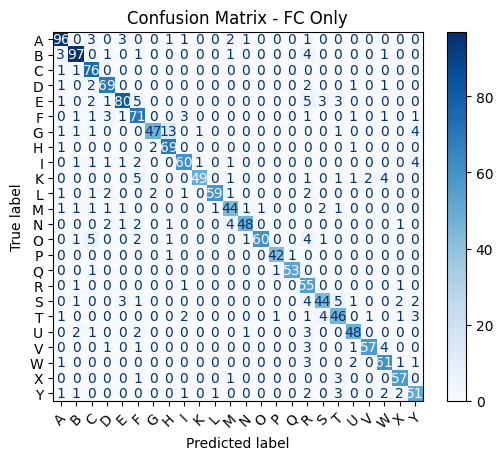

Test Accuracy: 0.9811
Weighted F1 Score: 0.9812


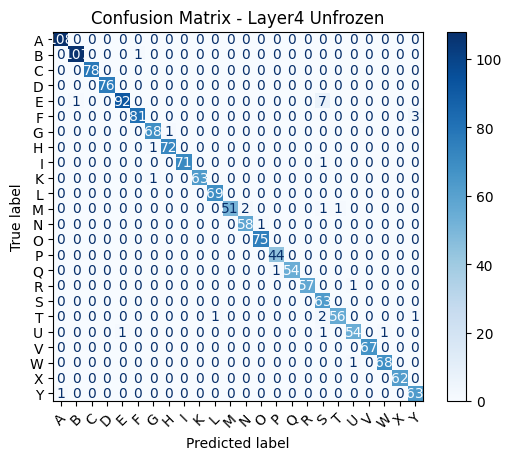

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# FC only
model_fc.eval()
all_preds_fc = []
all_labels_fc = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_fc(images)
        _, preds = torch.max(outputs, 1)
        all_preds_fc.extend(preds.cpu().numpy())
        all_labels_fc.extend(labels.cpu().numpy())
accuracy = accuracy_score(all_labels_fc, all_preds_fc)
f1 = f1_score(all_labels_fc, all_preds_fc, average="weighted")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")
class_names = [k for k, v in sorted(test_dataset.label_map.items(), key=lambda x: x[1])]
cm = confusion_matrix(all_labels_fc, all_preds_fc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - FC Only")
plt.show()

# Layer4 unfrozen
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="weighted")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - Layer4 Unfrozen")
plt.show()

# **Final Model Performance Comparison**

---



Fine-tuned ResNet18 achieved the best overall performance, significantly outperforming both the custom CNN and regular ResNet18.

In [30]:
results = pd.DataFrame({
    "Model": ["Custom CNN", "Regular ResNet18", "Fine-Tuned ResNet18"],
    "Accuracy":  [0.8093, 0.7857, 0.9698],
    "Precision": [0.8093, 0.8100, 0.9711],
    "Recall":    [0.7916, 0.7857, 0.9698],
    "F1 Score":  [0.7934, 0.7874, 0.9699],
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Custom CNN,0.8093,0.8093,0.7916,0.7934
1,Regular ResNet18,0.7857,0.8100,0.7857,0.7874
2,Fine-Tuned ResNet18,0.9698,0.9711,0.9698,0.9699


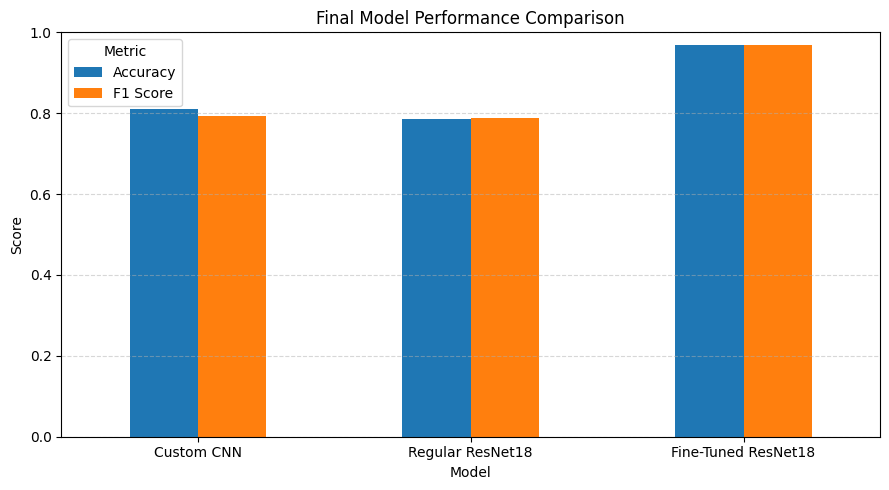

In [31]:
#Final Model Performance Comparison Bar Chart

import matplotlib.pyplot as plt

results.set_index("Model")[["Accuracy", "F1 Score"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Final Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()